In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pickle
import config.config as conf

In [2]:
# 파일 불러오기
with open(f'{conf.SNAPSHOT_DIR}/ba_chatgpt_df.pkl', 'rb') as f:
    df = pickle.load(f)


In [3]:
# 파일 불러오기
with open(f'{conf.SNAPSHOT_DIR}/df_not_answered.pkl', 'rb') as f:
    df_not_answered = pickle.load(f)
    


In [4]:
df_for_tot = df.groupby(['qna_creation_date']).sum()[['cnt']]

In [5]:
df_not_answered.tail()

,q_id,q_creationdate,a_id
5548750,68094389,2021-06-23 06:10:27.817,68117866.0
5548751,71840542,2022-04-12 09:50:10.227,71840601.0
5548752,77156348,2023-09-22 09:21:41.017,77157608.0
5548753,77975186,2024-02-11 00:10:39.440,NaN
5548754,65504045,2020-12-30 08:26:36.453,65506905.0


In [6]:
df_for_tot.loc['2022-11-30', :]

cnt    9443
Name: 2022-11-30, dtype: int64

In [7]:
c1 = conf.COLOR_LIST[0][3]
c2 = conf.COLOR_LIST[0][4]

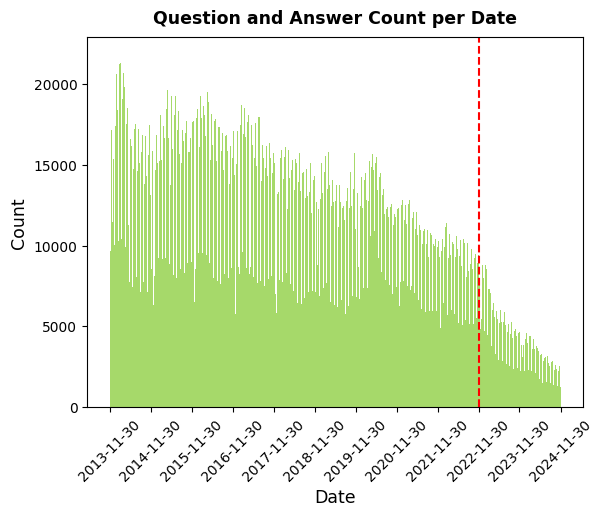

In [8]:
fig, ax = plt.subplots()


ax.bar(df_for_tot.index
    ,  height = df_for_tot['cnt']
    ,  color = c1
    , width=1.0, align='center'
      ) # hist type

ax.set_title("Question and Answer Count per Date", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Date", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Count", # add y-axis label
              fontsize = 12.5)

major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30', '2024-11-30']
ax.set_xticks(major_xticks)

ax.axvline('2022-11-30', # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)
plt.xticks(rotation=45)
plt.show();

In [9]:
df_for_tot[df_for_tot.index>='2020-11-30']

,cnt
qna_creation_date,
2020-11-30,11189
2020-12-01,12087
2020-12-02,12284
2020-12-03,12753
2020-12-04,11621
...,...
2024-11-26,2474
2024-11-27,2345
2024-11-28,2185


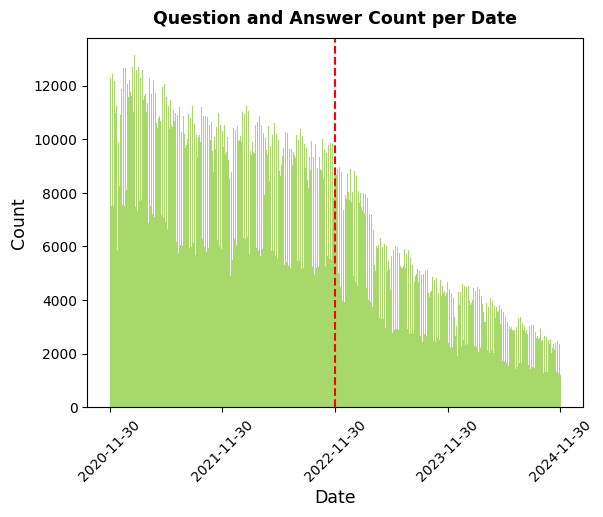

In [10]:
fig, ax = plt.subplots()

ax.bar(df_for_tot[df_for_tot.index>='2020-11-30'].index
    ,  height = df_for_tot[df_for_tot.index>='2020-11-30']['cnt']
    ,  color = c1
    , width=1.0, align='center'
      ) # hist type

ax.set_title("Question and Answer Count per Date", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Date", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Count", # add y-axis label
              fontsize = 12.5)

major_xticks = ['2020-11-30', '2021-11-30', '2022-11-30', '2023-11-30', '2024-11-30']
ax.set_xticks(major_xticks)

ax.axvline('2022-11-30', # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)
plt.xticks(rotation=45)
plt.show();

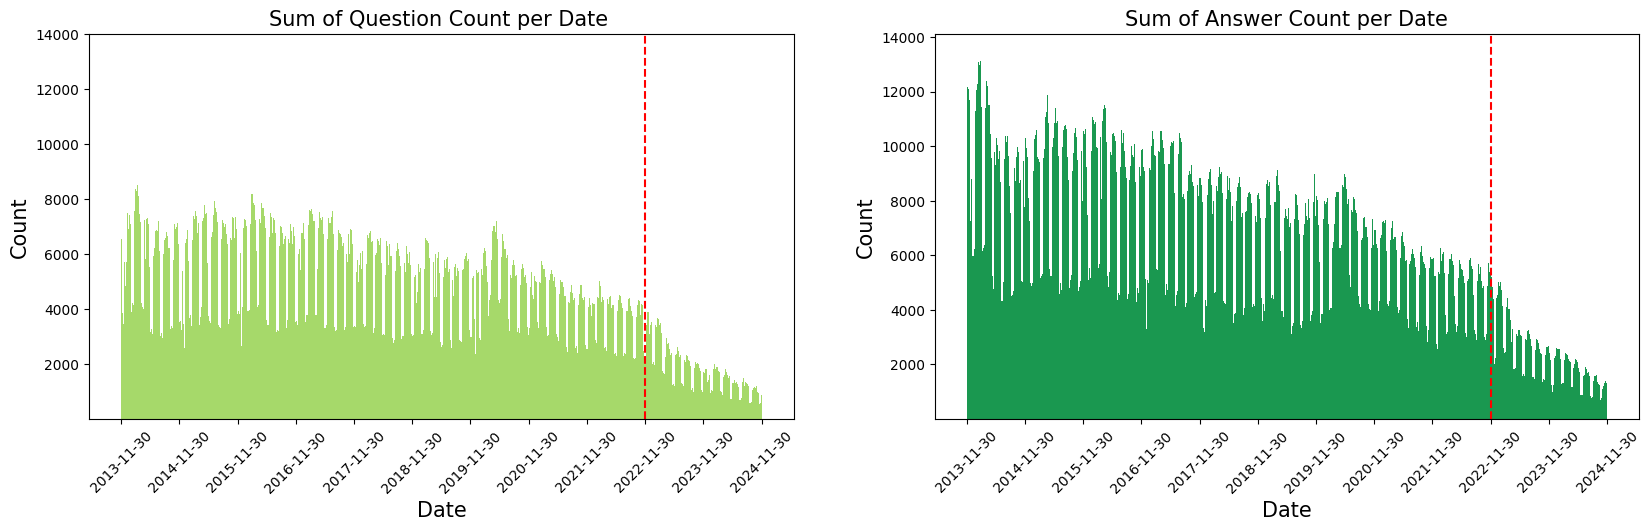

In [11]:
### create a figure with multiple subplots


sharey = 'none' ## 또는 sharey=False
sharex = 'none' ## 또는 sharex=False

fig, axs = plt.subplots(1, 2, figsize = (20, 5), sharey=sharey, sharex=sharex)
# plt.xticks(rotation=45)
major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30', '2024-11-30']
yticks = np.arange(2000, 16000, 2000)
axs[0].bar(df.loc[df['posttypeid']=='1', 'qna_creation_date']
        ,  df.loc[df['posttypeid']=='1', 'cnt']
        ,  color = c1
        ,  width=1.0 , align='center'
        # ,  edgecolor = 'black'
      ) # hist type
axs[0].set_title('Sum of Question Count per Date ', fontsize = 15)
axs[0].set_xlabel('Date', fontsize = 15)
axs[0].set_ylabel('Count', fontsize = 15)
axs[0].set_xticks(major_xticks)
axs[0].set_yticks(yticks)
axs[0].axvline(major_xticks[-3], # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)
axs[0].tick_params(axis='x', rotation=45)
# axs[0].yticks(yt)

axs[1].bar(df.loc[df['posttypeid']=='2', 'qna_creation_date']
        ,  df.loc[df['posttypeid']=='2', 'cnt']
        ,  color = c2
        ,  width=1.0 , align='center'
        # ,  edgecolor = 'black'
      ) # hist type
axs[1].set_title('Sum of Answer Count per Date', fontsize = 15)
axs[1].set_xlabel('Date', fontsize = 15)
axs[1].set_ylabel('Count', fontsize = 15)
axs[1].set_xticks(major_xticks)
axs[1].set_yticks(yticks)
axs[1].axvline(major_xticks[-3], # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)
axs[1].tick_params(axis='x', rotation=45)

plt.show();

In [12]:
df_for_tot_rset = df_for_tot.reset_index()

In [13]:
df_for_tot_rset['weekday_nm'] = pd.to_datetime(df_for_tot_rset['qna_creation_date']).dt.day_name()
df_for_tot_rset['weekday'] = pd.to_datetime(df_for_tot_rset['qna_creation_date']).dt.weekday

In [14]:
df_for_tot_rset

,qna_creation_date,cnt,weekday_nm,weekday
0,2013-11-30,9402,Saturday,5
1,2013-12-01,8987,Sunday,6
2,2013-12-02,16868,Monday,0
3,2013-12-03,18707,Tuesday,1
4,2013-12-04,19245,Wednesday,2
...,...,...,...,...
4014,2024-11-26,2474,Tuesday,1
4015,2024-11-27,2345,Wednesday,2
4016,2024-11-28,2185,Thursday,3
4017,2024-11-29,2025,Friday,4


In [15]:
df_weekday_mean = df_for_tot_rset.groupby(['weekday_nm', 'weekday']).mean([['cnt']]).reset_index()

In [16]:
df_weekday_mean.sort_values(by = 'weekday', inplace=True)

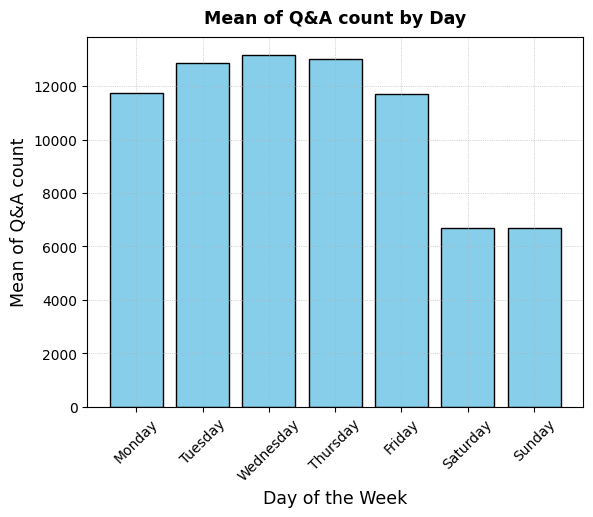

In [17]:
fig, ax = plt.subplots()

ax.bar(df_weekday_mean.weekday_nm
    ,  height = df_weekday_mean['cnt']
    ,  color = 'skyblue'
    ,  edgecolor = 'black'
      ) # hist type

ax.set_title("Mean of Q&A count by Day", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Day of the Week", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Mean of Q&A count", # add y-axis label
              fontsize = 12.5)

label_list = list(df_weekday_mean['weekday_nm'])
tick_values = np.arange(len(label_list))
ax.set_xticks(ticks = tick_values ,labels = label_list, rotation =45)


# fig.text(0.7, 0.76, color = 'red', fontsize = 12.5,  s='Mean: ' + str(round(np.mean(viewcount_df['ViewCount_question']), 2))) #
# fig.text(0.41, 0.77, s='pct_change: ' + str(decrease_2122)) #
# fig.text(0.66, 0.65, s='pct_change: ' + str(decrease_2223)) #

ax.grid(True, linestyle = ':', linewidth = 0.5) # add grid

plt.show();

In [18]:
df_not_answeredviz = df_not_answered[['q_id', 'q_creationdate', 'a_id']]

In [19]:
df_not_answered.head()

,q_id,q_creationdate,a_id
0,71564856,2022-03-21 22:25:50.703,71565333.0
1,77205420,2023-09-30 01:50:31.227,77208467.0
2,77205420,2023-09-30 01:50:31.227,77205466.0
3,78545172,2024-05-28 15:41:45.837,78545260.0
4,67520513,2021-05-13 13:56:39.080,NaN


In [20]:
df_not_answeredviz['dt'] = pd.to_datetime(df_not_answeredviz['q_creationdate']).dt.date
df_not_answeredviz['dt'] = df_not_answeredviz['dt'].astype('str')

In [21]:
df_tot_q = df_not_answeredviz.groupby('dt').count()[['q_id']].reset_index()

In [22]:
df_not_a = df_not_answeredviz[df_not_answeredviz['a_id'].isna()].groupby('dt').count()[['q_id']].reset_index()

In [23]:
df_not_a[df_not_a['dt'] =='2022-12-04']

,dt,q_id
763,2022-12-04,458


In [24]:
df_totq_nota = pd.merge(df_tot_q, df_not_a, on ='dt', how='left')

In [25]:
df_totq_nota.columns = ['dt', 'totq', 'nota']

In [26]:
df_totq_nota['nota_rate'] = np.round(df_totq_nota['nota']/df_totq_nota['totq']*100, 3)
df_totq_nota['a_rate'] = 100- df_totq_nota['nota_rate']

In [27]:
df_totq_nota

,dt,totq,nota,nota_rate,a_rate
0,2020-11-01,4096,491,11.987,88.013
1,2020-11-02,6360,883,13.884,86.116
2,2020-11-03,6823,855,12.531,87.469
3,2020-11-04,6712,881,13.126,86.874
4,2020-11-05,6894,910,13.200,86.800
...,...,...,...,...,...
1486,2024-11-26,1311,514,39.207,60.793
1487,2024-11-27,1166,468,40.137,59.863
1488,2024-11-28,1162,419,36.059,63.941
1489,2024-11-29,1002,376,37.525,62.475


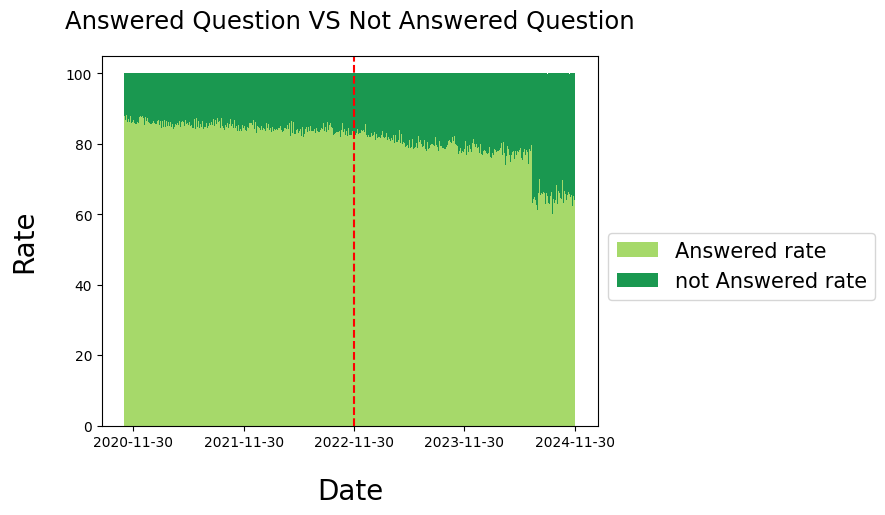

In [44]:
fig, ax = plt.subplots()

ax.bar(df_totq_nota['dt'], df_totq_nota['a_rate'], color=c1, label = 'Answered rate', align='center', width=1.0)
ax.bar(df_totq_nota['dt'], df_totq_nota['nota_rate'], bottom = df_totq_nota['a_rate'], color = c2, label = 'not Answered rate', align='center', width=1.0)

ax.set_xlabel('Date', fontsize = 20, labelpad = 20)
ax.set_ylabel('Rate', fontsize = 20, labelpad = 20)
ax.set_title('Answered Question VS Not Answered Question', fontsize = 17.5, pad = 20)
major_xticks = ['2020-11-30','2021-11-30', '2022-11-30', '2023-11-30', '2024-11-30']
ax.set_xticks(major_xticks)
# ax.tick_params(axis = 'both', labelsize = 17.5)

ax.legend( title_fontsize = 15, fontsize = 15,
          bbox_to_anchor = (1, 0.55))


ax.axvline('2022-11-30', # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)

In [29]:
df_totq_nota[df_totq_nota['dt'] =='2022-12-04']

,dt,totq,nota,nota_rate,a_rate
763,2022-12-04,2798,458,16.369,83.631


In [30]:
df_pivot = df.pivot_table(index='qna_creation_date', columns='posttypeid', values = 'cnt').reset_index()

In [31]:
df_pivot['q_over_a']=(df_pivot['2']/df_pivot['1'])*100

In [32]:
df_pivot.head()

posttypeid,qna_creation_date,1,2,q_over_a
0,2013-11-30,3657.0,5745.0,157.095980
1,2013-12-01,3596.0,5391.0,149.916574
2,2013-12-02,6565.0,10303.0,156.938309
3,2013-12-03,7208.0,11499.0,159.531077
4,2013-12-04,7431.0,11814.0,158.982640


In [33]:
df_pivot

posttypeid,qna_creation_date,1,2,q_over_a
0,2013-11-30,3657.0,5745.0,157.095980
1,2013-12-01,3596.0,5391.0,149.916574
2,2013-12-02,6565.0,10303.0,156.938309
3,2013-12-03,7208.0,11499.0,159.531077
4,2013-12-04,7431.0,11814.0,158.982640
...,...,...,...,...
4014,2024-11-26,1137.0,1337.0,117.590150
4015,2024-11-27,1041.0,1304.0,125.264169
4016,2024-11-28,1005.0,1180.0,117.412935
4017,2024-11-29,878.0,1147.0,130.637813


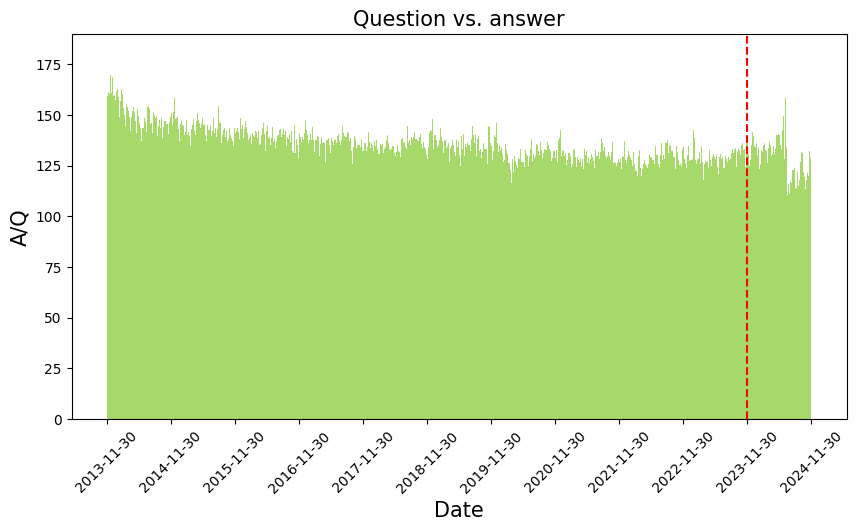

In [45]:
### create a figure with multiple subplots

fig, axs = plt.subplots(figsize = (10, 5))
major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30', '2024-11-30']

axs.bar(df_pivot['qna_creation_date']
        ,  df_pivot['q_over_a']
        ,  color = c1
        ,  width = 1.0, align = 'center'
        # ,  edgecolor = 'black'
      ) # hist type
axs.set_title('Question vs. answer', fontsize = 15)
axs.set_xlabel('Date', fontsize = 15)
axs.set_ylabel('A/Q', fontsize = 15)
axs.set_xticks(major_xticks)
axs.axvline(major_xticks[-2], # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)
axs.tick_params(axis='x', rotation=45)


plt.show();

In [35]:
df_answered_cnt = df_not_answered.groupby(['q_creationdate', 'q_id']).count()[['a_id']].reset_index()

In [36]:
df_answered_cnt['date'] = pd.to_datetime(df_answered_cnt['q_creationdate']).dt.date.astype('str')

In [37]:
df_answered_cnt.loc[(df_answered_cnt['date']>= '2020-11-01')&(df_answered_cnt['date']<= '2020-11-30'), 'date'].unique()

array(['2020-11-01', '2020-11-02', '2020-11-03', '2020-11-04',
       '2020-11-05', '2020-11-06', '2020-11-07', '2020-11-08',
       '2020-11-09', '2020-11-10', '2020-11-11', '2020-11-12',
       '2020-11-13', '2020-11-14', '2020-11-15', '2020-11-16',
       '2020-11-17', '2020-11-18', '2020-11-19', '2020-11-20',
       '2020-11-21', '2020-11-22', '2020-11-23', '2020-11-24',
       '2020-11-25', '2020-11-26', '2020-11-27', '2020-11-28',
       '2020-11-29', '2020-11-30'], dtype=object)

In [38]:
df_answered_cnt.loc[(df_answered_cnt['date']>= '2020-11-01')&(df_answered_cnt['date']<= '2020-11-30'), 'a_id'].value_counts()

a_id
1     75675
0     23940
2     23289
3      6164
4      1685
5       542
6       184
7       100
8        51
9        38
11       16
10       16
12       10
16        8
13        7
19        5
18        4
42        3
14        3
26        3
20        3
15        2
17        2
24        2
29        1
33        1
27        1
21        1
30        1
31        1
49        1
Name: count, dtype: int64

In [39]:
df_answered_cnt.loc[(df_answered_cnt['date']>= '2021-11-01')&(df_answered_cnt['date']<= '2021-11-30'), 'a_id'].value_counts().sort_index()

a_id
0     23955
1     66779
2     19239
3      4920
4      1277
5       434
6       143
7        73
8        44
9        17
10       11
11       10
12        8
13        6
14        5
15        4
16        4
17        1
18        1
19        3
21        1
22        1
23        2
24        1
25        1
27        1
35        1
Name: count, dtype: int64

In [40]:
df_answered_cnt.loc[(df_answered_cnt['date']>= '2022-11-01')&(df_answered_cnt['date']<= '2022-11-30'), 'a_id'].value_counts()

a_id
1     63228
0     23163
2     16665
3      3802
4       935
5       254
6        97
7        45
8        23
9         9
10        6
14        3
11        3
15        2
18        2
13        1
16        1
23        1
Name: count, dtype: int64

In [41]:
df_answered_cnt.loc[(df_answered_cnt['date']>= '2023-11-01')&(df_answered_cnt['date']<= '2023-11-30'), 'a_id'].value_counts().to_frame()['count']

a_id
1     28569
0     13166
2      6775
3      1378
4       347
5       102
6        36
7         9
9         5
11        4
8         3
10        3
15        2
13        2
12        1
Name: count, dtype: int64

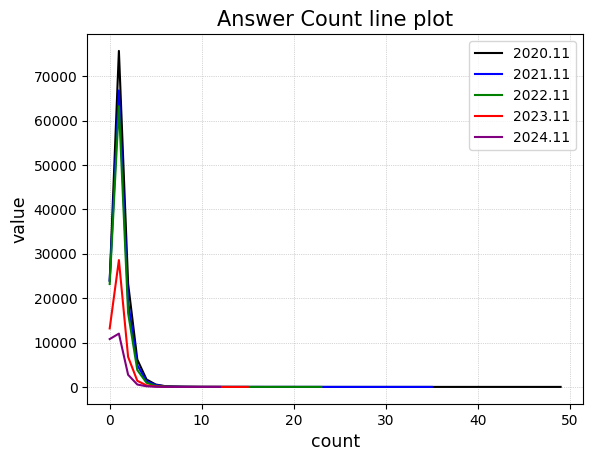

In [42]:
fig, ax = plt.subplots()

ax.plot(df_answered_cnt.loc[(df_answered_cnt['date']>= '2020-11-01')&(df_answered_cnt['date']<= '2020-11-30'), 'a_id'].value_counts().to_frame()['count'].sort_index(), # specify data
        color = 'black',
        label = '2020.11'
) 

ax.plot(df_answered_cnt.loc[(df_answered_cnt['date']>= '2021-11-01')&(df_answered_cnt['date']<= '2021-11-30'), 'a_id'].value_counts().to_frame()['count'].sort_index(), # specify data
        color = 'blue',
        label = '2021.11'
# label = ['question', 'answer']
) # create legened labels

ax.plot(df_answered_cnt.loc[(df_answered_cnt['date']>= '2022-11-01')&(df_answered_cnt['date']<= '2022-11-30'), 'a_id'].value_counts().to_frame()['count'].sort_index(), # specify data
        color = 'green',
         label = '2022.11'
        # label = ['question', 'answer']
        ) # create legened labels

ax.plot(df_answered_cnt.loc[(df_answered_cnt['date']>= '2023-11-01')&(df_answered_cnt['date']<= '2023-11-30'), 'a_id'].value_counts().to_frame()['count'].sort_index(), # specify data
        color = 'red', # bar color
        label = '2023.11'
        ) # create legened labels


ax.plot(df_answered_cnt.loc[(df_answered_cnt['date']>= '2024-11-01')&(df_answered_cnt['date']<= '2024-11-30'), 'a_id'].value_counts().to_frame()['count'].sort_index(), # specify data
        color = 'purple', # bar color
        label = '2024.11'
        ) # create legened labels





ax.set_title('Answer Count line plot', fontsize = 15) # title
ax.set_xlabel('count', fontsize = 12.5) # x-axis label
ax.set_ylabel('value', fontsize = 12.5) # y-axis label

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();